# Naive Bayes Model Training

Train a Naive Bayes model for email spam detection.

## Notebook Structure
1. Import modules
2. Load dataset
3. Split data
4. Create and train pipeline
5. Evaluate model
6. Visualize results
7. Save model (.pkl)

In [31]:
# scikit-learn components for building and evaluating the pipeline
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import (
    DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR,
    MODEL_OUTPUT_DIR, RESULTS_DIR
)

In [32]:
# Load the preprocessed combined dataset (Enron + TREC06P)
df = pd.read_csv(PROCESSED_DATA_DIR / "cleaned_combined_v3.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(2)

Shape: (118988, 11)
Columns: ['label', 'text', 'num_urls', 'num_exclamation', 'num_question', 'num_dollar', 'num_all_caps', 'num_numbers', 'word_count', 'capital_ratio', 'emoji_count']


,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
0,0,receiv nahou-msmbx01v [phonenumber] nahou- mic...,41,0,0,3,240,407,2319,0.145347,0
1,0,receiv nahou- [phonenumber] nacal-msmbx01v mic...,0,1,0,0,19,56,166,0.230851,0


In [33]:
# Check class balance between ham (0) and spam (1)
df["label"].value_counts()

label
1    60378
0    58610
Name: count, dtype: int64

In [34]:
# NUM_COLS (from src.features): URLs, exclamation/question/dollar counts, all-caps words, numbers, word count, capital ratio, emoji count
# Separate text and numeric features from target labels
TEXT_COL = "text"
TARGET = "label"

from src.features import NUM_COLS

X = df[[TEXT_COL] + NUM_COLS]
y = df[TARGET]

print(f"Samples: {len(X)}")
print(f"Numeric features: {len(NUM_COLS)}")
print(f"Target distribution:\n{y.value_counts()}")


Samples: 118988
Numeric features: 9
Target distribution:
label
1    60378
0    58610
Name: count, dtype: int64


In [35]:
# Stratified split preserves class proportions in both training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_train)}  Test: {len(y_test)}")
print(f"Train pos: {y_train.sum()}  Test pos: {y_test.sum()}")


Train: 95190  Test: 23798
Train pos: 48302  Test pos: 12076


In [36]:
# ComplementNB is well-suited for imbalanced text classification problems
# Combined feature space = 50000 TF-IDF dimensions + 9 numeric features
# ColumnTransformer applies TF-IDF to text and MinMaxScaler to numeric features
# ColumnTransformer handles both TF-IDF for text and scaling for numeric features
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=50000, sublinear_tf=True,
                             ngram_range=(1,2), max_df=0.7, min_df=3), "text"),
    ("numeric", MinMaxScaler(), NUM_COLS)
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", ComplementNB())
])

# Single fit call replaces separate tfidf, scaler, and model fitting
pipe.fit(X_train, y_train)

train_acc = pipe.score(X_train, y_train)
test_acc = pipe.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

# Show transformed dimensions for reference
X_train_transformed = pipe.named_steps["preprocessor"].transform(X_train)
X_test_transformed = pipe.named_steps["preprocessor"].transform(X_test)
print(f"Combined train shape: {X_train_transformed.shape}")
print(f"Combined test shape:  {X_test_transformed.shape}")


Train accuracy: 0.9793
Test accuracy:  0.9779
Combined train shape: (95190, 50009)
Combined test shape:  (23798, 50009)


In [37]:
# Generate predictions and probability/decision scores on the held-out test set
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("=== Naive Bayes (ComplementNB) Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

=== Naive Bayes (ComplementNB) Results ===
Accuracy:  0.9779
Precision: 0.9875
Recall:    0.9686
F1 Score:  0.9780
ROC-AUC:   0.9977

Confusion Matrix:
[[11574   148]
 [  379 11697]]

              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98     11722
        Spam       0.99      0.97      0.98     12076

    accuracy                           0.98     23798
   macro avg       0.98      0.98      0.98     23798
weighted avg       0.98      0.98      0.98     23798



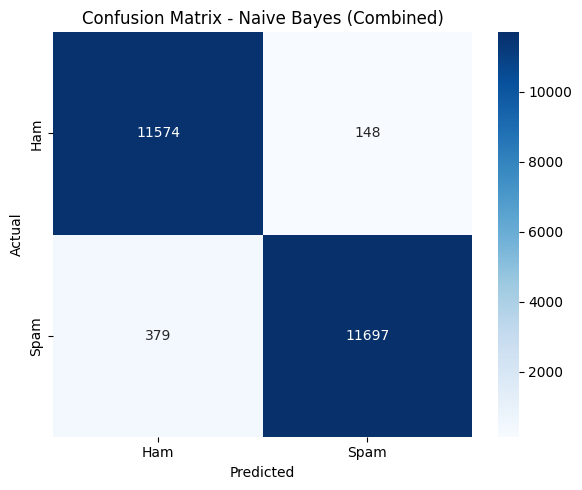

In [38]:
# Visualize prediction errors: rows = actual labels, columns = predicted labels
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes (Combined)")
plt.tight_layout()
plt.show()

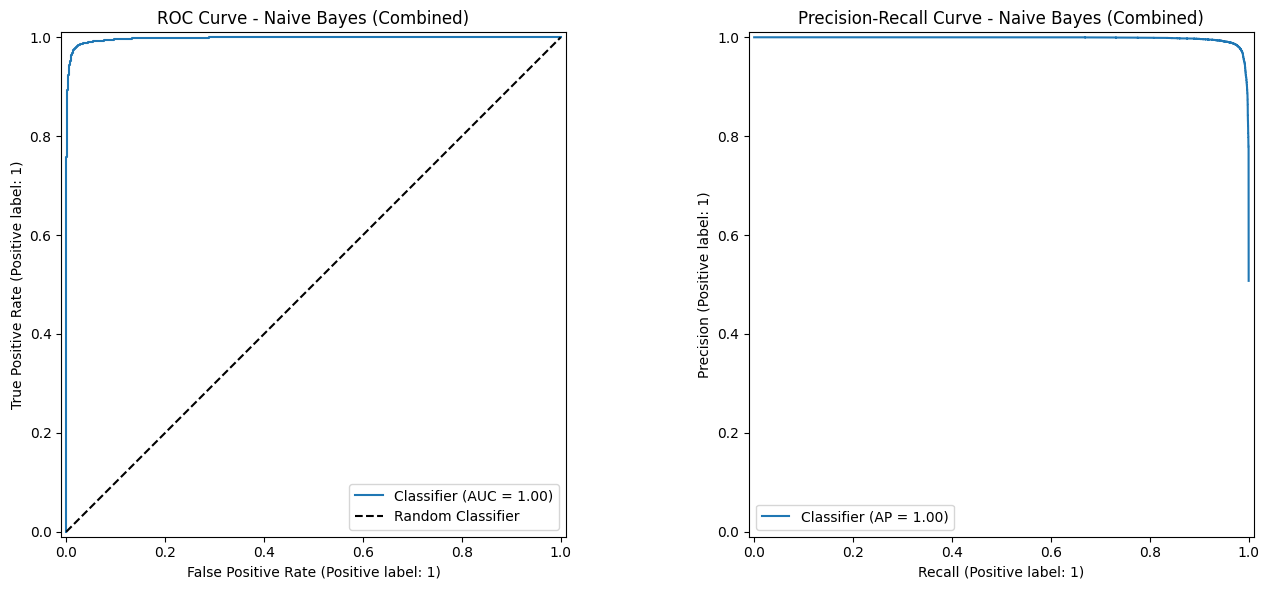

In [39]:
# Precision-Recall curve: useful when classes are imbalanced (focuses on positive class performance)
# ROC curve: True Positive Rate vs False Positive Rate across thresholds; AUC measures class separability
# ROC curve: plots True Positive Rate vs False Positive Rate across thresholds
# AUC quantifies the model's ability to distinguish between classes
# Precision-Recall curve: useful when classes are imbalanced
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax1)
ax1.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax1.set_title("ROC Curve - Naive Bayes (Combined)")
ax1.legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax2)
ax2.set_title("Precision-Recall Curve - Naive Bayes (Combined)")

plt.tight_layout()
plt.show()


Top 10 SPAM features (positive coefficients):
  g343bbl phonenumber            +7.1049
  id g343bbl                     +7.1049
  g343bbl                        +7.1049
  subject utf                    +6.2222
  replica watch                  +5.7890
  to utf                         +5.7605
  id utf                         +5.7032
  gmt mailer                     +5.4528
  replica classic                +5.4387
  rolex                          +5.2534

Top 10 HAM features (negative coefficients):
  correl thread                  -6.4193
  id ms                          -6.3576
  binari subject                 -6.3297
  classesmessag mime             -6.2827
  tnef                           -6.2495
  ms tnef                        -6.2495
  tnef correl                    -6.2494
  has attach                     -6.1791
  ms has                         -6.1791
  attach ms                      -6.1288


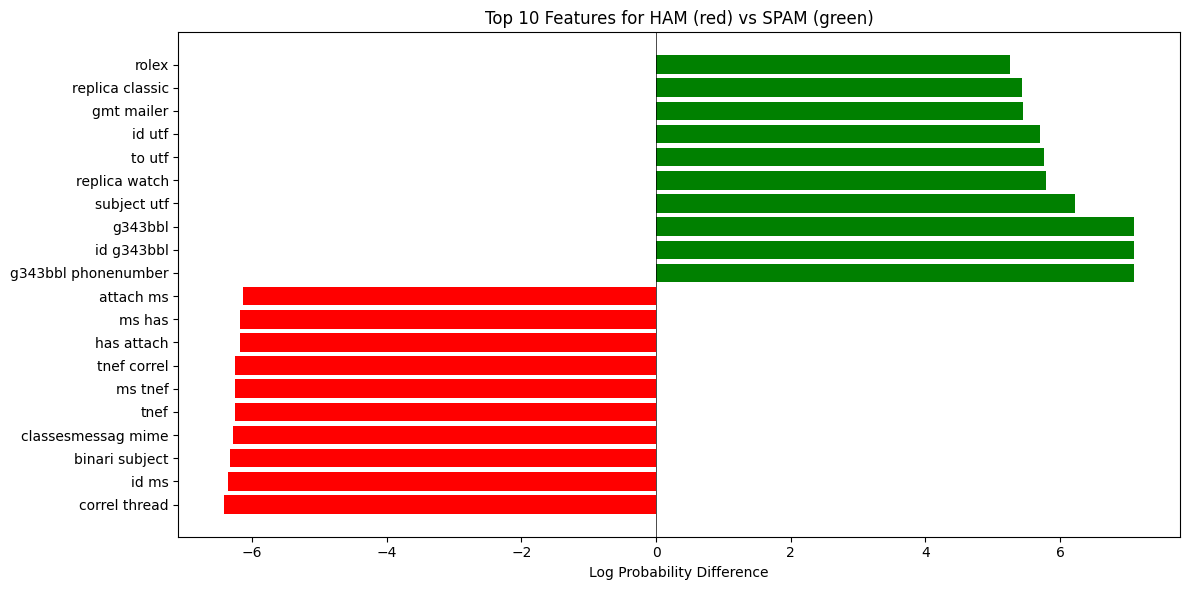

In [40]:
# feature_log_prob_ difference: positive values indicate spam-associated features, negative = ham
# Extract feature names from the TF-IDF step inside the pipeline
tfidf = pipe.named_steps["preprocessor"].named_transformers_["text"]
feature_names = tfidf.get_feature_names_out().tolist() + NUM_COLS
# feature_log_prob_ difference measures how much each feature contributes to spam vs ham
# Positive values indicate spam-associated features, negative values indicate ham features
coefs = pipe.named_steps["clf"].feature_log_prob_[1] - pipe.named_steps["clf"].feature_log_prob_[0]

top_spam_idx = np.argsort(coefs)[-10:]
top_ham_idx = np.argsort(coefs)[:10]

# Combine into a single list and assign colors based on sign
top_idx = list(top_ham_idx) + list(reversed(top_spam_idx))
top_names = [feature_names[i] for i in top_idx]
top_coefs = [coefs[i] for i in top_idx]
colors = ["red" if c < 0 else "green" for c in top_coefs]

# Horizontal bar chart for top features
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_idx)), top_coefs, color=colors)
plt.yticks(range(len(top_idx)), top_names)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("Log Probability Difference")
plt.title("Top 10 Features for HAM (red) vs SPAM (green)")

# Also print the numeric values for reference
print("Top 10 SPAM features (positive coefficients):")
for i in reversed(top_spam_idx):
    print(f"  {feature_names[i]:30s} {coefs[i]:+.4f}")
print("\nTop 10 HAM features (negative coefficients):")
for i in top_ham_idx:
    print(f"  {feature_names[i]:30s} {coefs[i]:+.4f}")

plt.tight_layout()
plt.show()


In [45]:
# Parse a .eml file and run it through the full trained pipeline
from src.features import extract_features
from src.preprocess import parse_eml


email2 = parse_eml(PROCESSED_DATA_DIR / "email-testing-5.eml")[1]
sample_email = pd.Series([email2])
sample_features = extract_features(sample_email)



# Pipeline handles all preprocessing (TF-IDF + scaling) and prediction in one call
sample_pred = pipe.predict(sample_features)


print(f"number of emojis: {sample_features['emoji_count'].values[0]}")
print(f"Sample email prediction: {'SPAM' if sample_pred[0] == 1 else 'HAM'}")
print(f"Sample email ham probability: {pipe.predict_proba(sample_features)[0, 0]:.4f}")
print(f"Sample email spam probability: {pipe.predict_proba(sample_features)[0, 1]:.4f}")


number of emojis: 0
Sample email prediction: HAM
Sample email ham probability: 0.8902
Sample email spam probability: 0.1098


In [46]:
# Run predefined test emails through the trained pipeline for qualitative evaluation
from src.test_emails import test_emails

# Pipeline handles all preprocessing + prediction in one call
df_test = extract_features(pd.Series(test_emails))
y_test_pred = pipe.predict(df_test)
y_test_prob = pipe.predict_proba(df_test)
for i, (email, pred, probs) in enumerate(zip(test_emails, y_test_pred, y_test_prob)):
    label = "SPAM" if pred == 1 else "HAM"
    ham_p, spam_p = probs[0], probs[1]
    print(f"[{i}] {label} (ham: {ham_p:.2%}, spam: {spam_p:.2%}) — {email[:70]}...")


[0] SPAM (ham: 5.81%, spam: 94.19%) — Congratulations! You won $1000 free cash prize. Click here now to clai...
[1] HAM (ham: 99.03%, spam: 0.97%) — Hi John, please find attached the meeting notes from yesterday's call....
[2] SPAM (ham: 13.81%, spam: 86.19%) — URGENT: Your account has been suspended. Verify now at http://scam-sit...
[3] HAM (ham: 99.20%, spam: 0.80%) — Can we reschedule tomorrow's lunch to 1pm instead?...
[4] SPAM (ham: 0.50%, spam: 99.50%) — Buy cheap v1agra 100% free shipping limited offer act now!!!...
[5] HAM (ham: 99.58%, spam: 0.42%) — For your Assignment 1, word count of 3100 is already slightly too high...
[6] HAM (ham: 99.39%, spam: 0.61%) — Please be reminded that the Assignment 1 report is due this Sunday (17...
[7] HAM (ham: 96.06%, spam: 3.94%) — Show, Last weekend, I was sick and couldn't do much of anything. So I ...
[8] HAM (ham: 79.59%, spam: 20.41%) — Supporters can now pay you in USDC, and the money lands in your accoun...
[9] HAM (ham: 99.48%, spam

In [43]:
# Save the entire trained pipeline (preprocessor + classifier/clustering) for later deployment
# Single dump: the pipeline contains preprocessor (TF-IDF + scaler) and classifier
joblib.dump(pipe, MODEL_OUTPUT_DIR / "naive_bayes_pipeline.pkl")
print(f"Saved pipeline to {MODEL_OUTPUT_DIR / 'naive_bayes_pipeline.pkl'}")


Saved pipeline to C:\Users\aungm\university\computing\cos30049-email-spam-detection\models\naive_bayes_pipeline.pkl
